In [1]:
import copy

from sqlalchemy.dialects.mssql.information_schema import columns
%pwd 'D:\Python_2\MLogic_project\Yuperio\Прогноз продаж 12_2025\'

'D:\\Python_2\\MLogic_project\\Yuperio\\Прогноз продаж 12_2025\\ipynb'

In [2]:
import pandas as pd
import datetime
from dateutil.relativedelta import relativedelta
import copy

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
from pykalman import KalmanFilter

In [3]:
df_xls = pd.read_excel('temp_8_9_10_итог_с_июлем.xlsx')

In [4]:
df_xls.head()


,location_mdlp_id,gc_address,gc_lat,gc_lng,territory,geoball,2024-01-01,2024-02-01,2024-03-01,2024-04-01,...,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,class,method,2025-08-01,2025-09-01,2025-10-01
0,166.0,"Россия, Москва, Митинская улица, 43",55.849565,37.352767,KAM Moscow_3,9.0,18.0,7.0,14.0,15.0,...,16.0,30,19.0,27.0,20.0,Стабильная,LR,19,19.0,20.0
1,169.0,"Россия, Москва, улица Маршала Федоренко, 12",55.881722,37.488844,KAM Moscow_15,3.0,13.0,18.0,16.0,16.0,...,34.0,38,21.0,27.0,18.0,Стабильная,LR,22,22.0,21.0
2,170.0,"Россия, Москва, Лукинская улица, 5к1",55.645517,37.342373,KAM SpCardio Central_3,5.0,15.0,3.0,13.0,6.0,...,13.0,26,10.0,14.0,18.0,Стабильная,LR,21,22.0,23.0
3,171.0,"Россия, Москва, Сходненская улица, 36/11",55.842994,37.439625,KAM Moscow_3,8.0,NaN,NaN,NaN,NaN,...,0.0,0,3.0,2.0,0.0,Нестабильная,Median+SMA,1,1.0,1.0
4,172.0,"Россия, Москва, Уссурийская улица, 9",55.823980,37.819082,KAM Moscow_VAO_2,7.0,11.0,6.0,14.0,9.0,...,29.0,23,36.0,39.0,26.0,Стабильная,LR,30,31.0,33.0


In [5]:
date_0 = datetime.datetime.strptime('2024-01-01', '%Y-%m-%d')
ls_date = [ (date_0 + relativedelta(months=num_mes)).strftime('%Y-%m-%d') for num_mes in range(19)]
df_xls = df_xls[ls_date]

# Порядковый номер записи
num_rec = 5
# Список продаж за 19 месяцев
ls_prod_etl = df_xls.iloc[num_rec].tolist()
ls_prod_old = ls_prod_etl[:-3]

print(f'{ls_prod_etl=}')
print(f'{ls_prod_old=}')


ls_prod_etl=[16.0, 23.0, 17.0, 27.0, 11.0, 16.0, 19.0, 21.0, 21.0, 16.0, 24.0, 10.0, 17.0, 11.0, 17.0, 16, 23.0, 24.0, 22.0]
ls_prod_old=[16.0, 23.0, 17.0, 27.0, 11.0, 16.0, 19.0, 21.0, 21.0, 16.0, 24.0, 10.0, 17.0, 11.0, 17.0, 16]


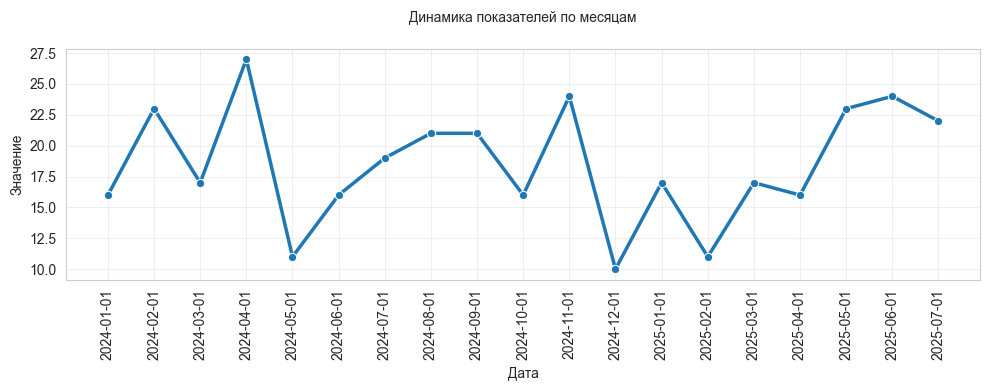

In [6]:
df_etl = pd.DataFrame({
    'Дата': ls_date,
    'Значение': ls_prod_etl
    })

plt.figure(figsize=(10, 4))
sns.lineplot(data=df_etl, x='Дата', y='Значение', marker='o', linewidth=2.5)
plt.title('Динамика показателей по месяцам', fontsize=10, pad=20)
plt.xlabel('Дата', fontsize=10)
plt.ylabel('Значение', fontsize=10)
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Прогноз на основе фильтра Кальмана**

In [7]:
def kalman_forecast(data, n_forecast, n_dim_state=2):
    """
    Прогнозирование временного ряда с помощью фильтра Калмана.

    Параметры:
    data : одномерный массив (list, np.array)
        Исторические данные (например, продажи за 22 месяца).
    n_forecast : int
        Количество периодов для прогноза в будущее.
    n_dim_state : int
        Размерность состояния системы. 2 подходит для модели с уровнем и трендом.

    Возвращает:
    smoothed_state_means : np.array
        Сглаженные оценки состояний за исторический период.
    forecast : np.array
        Прогноз на n_forecast шагов вперед.
    """

    # Преобразуем данные в numpy массив и задаем измерения как двумерный столбец
    measurements = np.array(data).reshape(-1, 1)

    # 1. Инициализация фильтра Калмана
    kf = KalmanFilter(
        n_dim_obs=1,           # Измеряем только одну величину - объем продаж
        n_dim_state=n_dim_state, # Состояние: [уровень, тренд]

        # Матрица перехода состояния. Предполагаем постоянную скорость (линейный тренд)
        # Например, для состояния [x, dx]: новое x = x + dx; новое dx = dx
        transition_matrices=[[1, 1],
                             [0, 1]],

        # Матрица наблюдения. Мы наблюдаем только первый компонент состояния (уровень)
        observation_matrices=[[1, 0]],

        # Начальная ковариация состояния (высокая неопределенность)
        initial_state_covariance=np.eye(n_dim_state) * 10,

        # Ковариация шума процесса (как быстро меняется состояние)
        transition_covariance=np.eye(n_dim_state) * 0.01,

        # Ковариация шума измерений (уровень шума в данных о продажах)
        observation_covariance=1.0
    )

    # 2. Обучение фильтра на исторических данных (можно настроить итерации EM)
    kf = kf.em(measurements, n_iter=5)  # Раскомментировать для автоматической настройки параметров

    # 3. Применение фильтра и сглаживания к историческим данным
    smoothed_state_means, _ = kf.smooth(measurements)

    # 4. Прогнозирование будущих состояний
    forecast = []
    current_state = smoothed_state_means[-1]  # Последнее сглаженное состояние
    filter_results = kf.filter(measurements)
    current_covariance = filter_results[1][-1]  # Последняя ковариация

    # Преобразуем матрицы в numpy массивы для работы с ними
    transition_matrices = np.array(kf.transition_matrices)
    observation_matrices = np.array(kf.observation_matrices)
    transition_covariance = np.array(kf.transition_covariance)

    for _ in range(n_forecast):
        # Предсказание следующего состояния
        current_state = np.dot(transition_matrices, current_state)
        current_covariance = np.dot(np.dot(transition_matrices, current_covariance),
                                    transition_matrices.T) + transition_covariance
        # Преобразование состояния в прогнозируемое измерение (продажи)
        predicted_measurement = np.dot(observation_matrices, current_state)
        forecast.append(predicted_measurement[0])

    return smoothed_state_means[:, 0], np.array(forecast)

In [8]:
# --- Пример использования с вашими данными ---
# Допустим, ваши данные о продажах за 22 месяца находятся в списке sales_data

sales_data = ls_prod_old

# Сглаживание исторических данных и прогноз на 3 месяца вперед
smoothed_sales, sales_forecast = kalman_forecast(sales_data, n_forecast=3)
sales_forecast = np.round(sales_forecast)

print("Сглаженные исторические значения:", smoothed_sales)
print("Прогноз на следующие 3 периода:", sales_forecast)

Сглаженные исторические значения: [19.09951436 18.96213214 18.80773499 18.63988958 18.45199914 18.25694659
 18.05148238 17.83225224 17.5969892  17.34630762 17.08555065 16.81187162
 16.53882107 16.26417429 15.99340196 15.72220645]
Прогноз на следующие 3 периода: [15. 15. 15.]


In [9]:
ls_prod_new = copy.deepcopy(ls_prod_old)
ls_prod_new.extend(sales_forecast)

In [10]:
# Расчет линейного тренда
from scipy import stats

sales = np.array(ls_prod_etl)
ls_months = range(len(ls_date))
months = np.array(ls_months)

slope, intercept, r_value, p_value, std_err = stats.linregress(months, sales)

# Расчет линии тренда
trend_line = slope * months + intercept
trend_line

array([18.11052632, 18.15087719, 18.19122807, 18.23157895, 18.27192982,
       18.3122807 , 18.35263158, 18.39298246, 18.43333333, 18.47368421,
       18.51403509, 18.55438596, 18.59473684, 18.63508772, 18.6754386 ,
       18.71578947, 18.75614035, 18.79649123, 18.83684211])

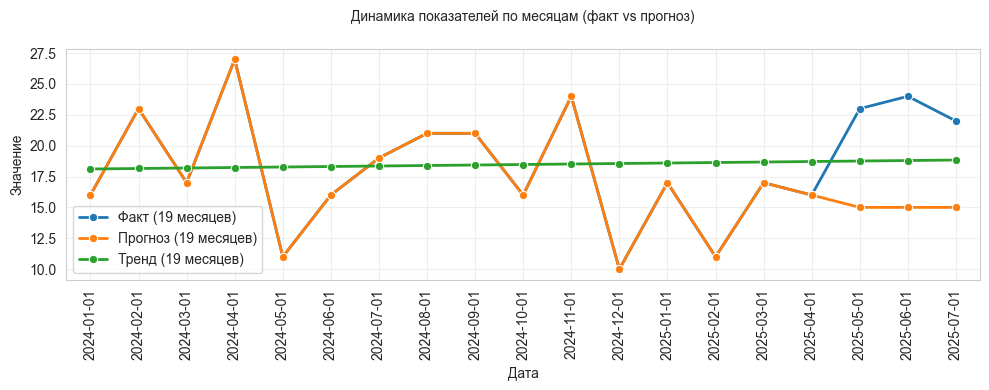

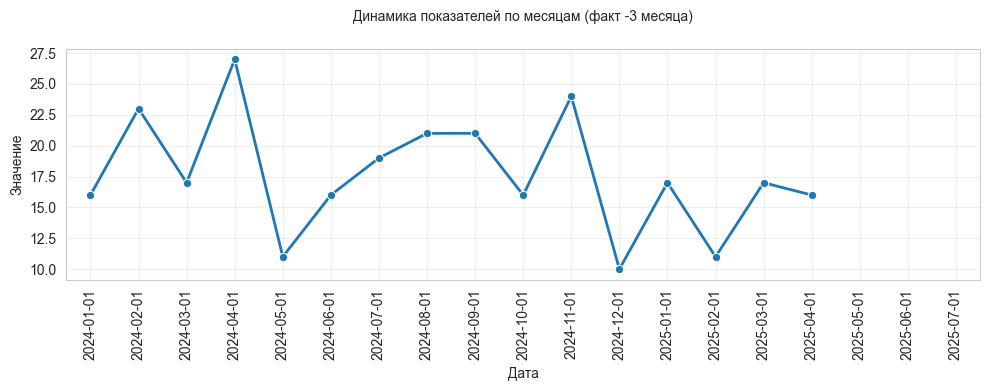

In [11]:
# общий список дат (строки, как в ls_date)
ls_date_str = [str(d) for d in ls_date]   # если ls_date уже строки 'YYYY-MM-DD' — ок
date2x = {d:i for i, d in enumerate(ls_date_str)}

# --- 1) Факт (19 месяцев) ---
df_etl_ = df_etl.copy()
df_etl_['Дата'] = df_etl_['Дата'].astype(str)
df_etl_['x'] = df_etl_['Дата'].map(date2x)

# --- 2) Факт (-3 месяца пустых) ---
n = len(ls_date_str)
m = len(ls_prod_old)
y_old = list(ls_prod_old) + [np.nan] * (n - m)

df_old_ = pd.DataFrame({
    'Дата': ls_date_str,
    'Значение': y_old
})
df_old_['x'] = df_old_['Дата'].map(date2x)

# --- 3) Прогноз (19 месяцев, если у тебя ls_prod_new уже длины 19) ---
df_new_ = pd.DataFrame({
    'Дата': [str(d) for d in ls_date],
    'Значение': ls_prod_new
})
df_new_['x'] = df_new_['Дата'].map(date2x)

# --- 4) Тренд 19 месяцев ---
df_trend_ = pd.DataFrame({
    'Дата': [str(d) for d in ls_date],
    'Значение': trend_line
})
df_trend_['x'] = df_trend_['Дата'].map(date2x)


# --- График 1 + График 3 на одной плоскости (разными цветами) ---
plt.figure(figsize=(10, 4))
ax = sns.lineplot(data=df_etl_, x='x', y='Значение', marker='o', linewidth=2.0, label='Факт (19 месяцев)')
sns.lineplot(data=df_new_, x='x', y='Значение', marker='o', linewidth=2.0, label='Прогноз (19 месяцев)', ax=ax)
sns.lineplot(data=df_trend_, x='x', y='Значение', marker='o', linewidth=2.0, label='Тренд (19 месяцев)', ax=ax)

plt.title('Динамика показателей по месяцам (факт vs прогноз)', fontsize=10, pad=20)
plt.xlabel('Дата', fontsize=10)
plt.ylabel('Значение', fontsize=10)
plt.xticks(ticks=range(len(ls_date_str)), labels=ls_date_str, rotation=90)
plt.xlim(-0.5, len(ls_date_str) - 0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Отдельно: факт (-3 месяца пустых) ---
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_old_, x='x', y='Значение', marker='o', linewidth=2.0)
plt.title('Динамика показателей по месяцам (факт -3 месяца)', fontsize=10, pad=20)
plt.xlabel('Дата', fontsize=10)
plt.ylabel('Значение', fontsize=10)
plt.xticks(ticks=range(len(ls_date_str)), labels=ls_date_str, rotation=90)
plt.xlim(-0.5, len(ls_date_str) - 0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Прогноз на основе расширенного фильтра Кальмана**

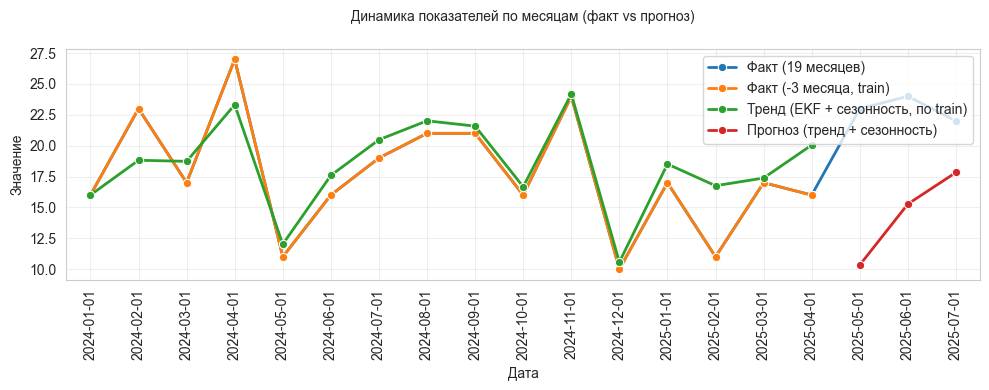

Сезонные коэффициенты (month -> factor):
{1: 1.027, 2: 0.966, 3: 1.004, 4: 1.184, 5: 0.623, 6: 0.93, 7: 1.098, 8: 1.189, 9: 1.17, 10: 0.909, 11: 1.32, 12: 0.581}

df_new_ (прогноз на 3 месяца, тренд + сезонность):
         Дата   Значение   x
0  2025-05-01  10.336805  16
1  2025-06-01  15.271492  17
2  2025-07-01  17.831521  18


In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from filterpy.kalman import ExtendedKalmanFilter
from filterpy.common import Q_discrete_white_noise

# --- Параметры EKF и прогноза ---
DAMP   = 0.90
Q_VAR  = 0.20
R_MEAS = 6.0
dt = 1.0
H = 3          # прогнозируем 3 месяца (последние 3 даты df_fact_)
m = 6          # окно для наклона/устойчивого старта (4..8)
SLOPE_K = 0.6  # приглушение наклона (0..1)

# --- Модель EKF: наблюдение (состояние -> измерение) ---
def hx(x):
    return np.array([x[0]])

# --- Модель EKF: якобиан наблюдения ---
def HJacobian(x):
    return np.array([[1., 0.]])

# --- Модель EKF: переход состояния (x, v) -> (x', v') ---
def fx(x, dt):
    new_x = x[0] + x[1] * dt
    new_v = x[1] * (DAMP ** dt)
    return np.array([new_x, new_v])

# --- Модель EKF: якобиан перехода ---
def FJacobian(x, dt):
    return np.array([[1., dt],
                     [0., (DAMP ** dt)]])

# --- Хелпер: сглаживание EKF для одномерного ряда ---
def ekf_smooth(y):
    ekf = ExtendedKalmanFilter(dim_x=2, dim_z=1)
    x0 = float(y[0])
    v0 = float(y[1] - y[0]) if len(y) >= 2 else 0.0
    ekf.x = np.array([x0, v0])
    ekf.P = np.diag([50., 50.])
    ekf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=Q_VAR)
    ekf.R = np.array([[R_MEAS]])
    ekf.FJacobian = lambda x: FJacobian(x, dt)
    ekf.fx = lambda x: fx(x, dt)

    trend = []
    for meas in y:
        ekf.predict()
        ekf.update(np.array([meas]), HJacobian, hx)
        trend.append(float(ekf.x[0]))
    return trend

# --- Подготовка train: df_old_ = "факт - 3 месяца" ---
df_old_2 = df_old_.copy()
df_old_2["Дата"] = df_old_2["Дата"].astype(str)
df_old_2["Значение"] = pd.to_numeric(df_old_2["Значение"], errors="coerce")
df_old_2 = df_old_2.sort_values("x").reset_index(drop=True)
df_old_2 = df_old_2[df_old_2["Значение"].notna()].reset_index(drop=True)

train_dates = df_old_2["Дата"].tolist()
train_z = df_old_2["Значение"].to_numpy(dtype=float)

# --- Подготовка df_fact_ (19 месяцев) только для сравнения и оси X ---
df_fact_ = df_etl_.copy()
df_fact_["Дата"] = df_fact_["Дата"].astype(str)
df_fact_["Значение"] = pd.to_numeric(df_fact_["Значение"], errors="coerce")
df_fact_ = df_fact_.sort_values("x").reset_index(drop=True)
df_fact_ = df_fact_[df_fact_["Значение"].notna()].reset_index(drop=True)

full_dates = df_fact_["Дата"].tolist()
if len(full_dates) < H:
    raise ValueError(f"В df_fact_ меньше {H} точек")
forecast_dates = full_dates[-H:]  # последние 3 месяца (на них кладём прогноз)

# --- Шаг 1: тренд на train (черновой), чтобы оценить сезонные коэффициенты ---
trend0 = ekf_smooth(train_z)

# --- Шаг 2: оценка годовой сезонности (мультипликативно): factor[month] = median(y / trend) ---
eps = 1e-6
train_months = pd.to_datetime(train_dates, errors="coerce").month.to_numpy()
ratios = train_z / np.maximum(np.array(trend0), eps)

season = {}
for mo in range(1, 13):
    vals = ratios[train_months == mo]
    season[mo] = float(np.median(vals)) if len(vals) else 1.0

# --- Нормализация сезонности: среднее факторов = 1.0 (чтобы не менять общий уровень) ---
mean_season = float(np.mean(list(season.values())))
if mean_season > 0:
    for mo in season:
        season[mo] = season[mo] / mean_season

# --- Шаг 3: снимаем сезонность на train и строим "базовый тренд" по десезонализированным данным ---
y_ds = np.array([train_z[i] / max(season[int(train_months[i])], eps) for i in range(len(train_z))], dtype=float)
trend_ds = ekf_smooth(y_ds)

# --- Шаг 4: тренд для графика (в масштабе продаж): trend * season(month) ---
trend_season = np.array([trend_ds[i] * season[int(train_months[i])] for i in range(len(trend_ds))], dtype=float)

# --- Шаг 5: прогноз на 3 месяца как продление БАЗОВОГО тренда + возврат сезонности ---
base_start = float(np.median(y_ds[-min(m, len(y_ds)):]))
base_slope = float(np.mean(np.diff(trend_ds[-min(m, len(trend_ds)):]))) if len(trend_ds) > 1 else 0.0
base_slope *= SLOPE_K

base_fc = base_start + base_slope * np.arange(1, H + 1)

fc_months = pd.to_datetime(forecast_dates, errors="coerce").month.to_numpy()
forecast = np.array([base_fc[i] * season[int(fc_months[i])] for i in range(H)], dtype=float)
forecast = np.maximum(forecast, 0.0)  # продажи не должны быть < 0

# --- Ось X как у тебя: по full_dates (19 месяцев) ---
ls_date_str = full_dates
date2x = {d: i for i, d in enumerate(ls_date_str)}

df_fact_["x"] = df_fact_["Дата"].map(date2x)
df_old_2["x"] = df_old_2["Дата"].map(date2x)

df_trend_ = pd.DataFrame({"Дата": train_dates, "Значение": trend_season})
df_trend_["x"] = df_trend_["Дата"].map(date2x)

df_new_ = pd.DataFrame({"Дата": forecast_dates, "Значение": forecast})
df_new_["x"] = df_new_["Дата"].map(date2x)

# --- График: сравнение с df_fact_ + train + сезонный тренд + сезонный прогноз ---
plt.figure(figsize=(10, 4))
ax = sns.lineplot(data=df_fact_,  x="x", y="Значение", marker="o", linewidth=2.0, label="Факт (19 месяцев)")
sns.lineplot(data=df_old_2,  x="x", y="Значение", marker="o", linewidth=2.0, label="Факт (-3 месяца, train)", ax=ax)
sns.lineplot(data=df_trend_, x="x", y="Значение", marker="o", linewidth=2.0, label="Тренд (EKF + сезонность, по train)", ax=ax)
sns.lineplot(data=df_new_,   x="x", y="Значение", marker="o", linewidth=2.0, label="Прогноз (тренд + сезонность)", ax=ax)

plt.title("Динамика показателей по месяцам (факт vs прогноз)", fontsize=10, pad=20)
plt.xlabel("Дата", fontsize=10)
plt.ylabel("Значение", fontsize=10)
plt.xticks(ticks=range(len(ls_date_str)), labels=ls_date_str, rotation=90)
plt.xlim(-0.5, len(ls_date_str) - 0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Сезонные коэффициенты (month -> factor):")
print({k: round(v, 3) for k, v in season.items()})

print("\ndf_new_ (прогноз на 3 месяца, тренд + сезонность):")
print(df_new_)
